In [ ]:
Machine Learning with Python and PySpark
Dataset: Groceries
url:  https://raw.githubusercontent.com/shubhamjha97/association-rule-mining-apriori/master/data/groceries.csv
This program features the following concepts:
 - Statistical analysis
 - Data preprocessing for transactions
 - Apriori Algorithm using mlxtend (best for Colab)
 - Association Rules
 - Rich visualizations (Matplotlib, Seaborn, Plotly)
 *  Apriori analysis and apriori algorithm (for frequent itemset mining and association rule learning is used to
    find patterns in transactional datasets. An example is from online retailers where the page suggests the
    prospective buyer with the comment: "Who buys this also buys that".)

In [1]:
# Install Required Libraries
!pip install mlxtend plotly -q

# Import all required libraries
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!\n")

All libraries imported successfully!



In [2]:
# Load the dataset
url = "https://raw.githubusercontent.com/shubhamjha97/association-rule-mining-apriori/master/data/groceries.csv"

response = requests.get(url)
response.raise_for_status()

transactions = []
for line in response.text.splitlines():
    items = [item.strip() for item in line.strip().split(',') if item.strip()]
    if items:
        transactions.append(items)

print(f"Dataset Loaded Successfully!")
print(f"Total Transactions: {len(transactions):,}")

# Display sample transactions
df_sample = pd.DataFrame(transactions)
display(df_sample.head(8))

Dataset Loaded Successfully!
Total Transactions: 9,835


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,citrus fruit,semi-finished bread,margarine,ready soups,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,tropical fruit,yogurt,coffee,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,whole milk,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,pip fruit,yogurt,cream cheese,meat spreads,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,other vegetables,whole milk,condensed milk,long life bakery product,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
5,whole milk,butter,yogurt,rice,abrasive cleaner,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
6,rolls/buns,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
7,other vegetables,UHT-milk,rolls/buns,bottled beer,liquor (appetizer),None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [3]:
# One-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\n One-hot encoded basket shape: {basket.shape}")


 One-hot encoded basket shape: (9835, 169)


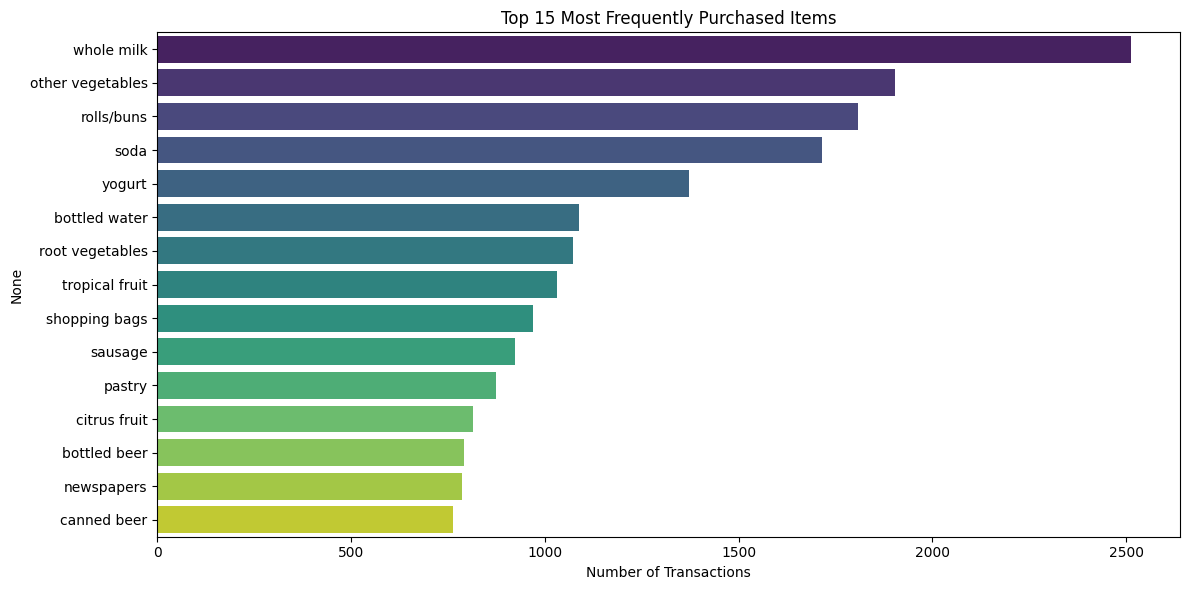


Top 10 Most Popular Items:
whole milk          2513
other vegetables    1903
rolls/buns          1809
soda                1715
yogurt              1372
bottled water       1087
root vegetables     1072
tropical fruit      1032
shopping bags        969
sausage              924
dtype: int64


In [4]:
# Statistical Analysis
item_freq = basket.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=item_freq.head(15).values, y=item_freq.head(15).index, palette='viridis')
plt.title('Top 15 Most Frequently Purchased Items')
plt.xlabel('Number of Transactions')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Popular Items:")
print(item_freq.head(10))

In [5]:
# Apriori
print("\n🔍 Running Apriori Algorithm...")
frequent_itemsets = apriori(basket, min_support=0.005, use_colnames=True)

print(f"Frequent Itemsets Found: {len(frequent_itemsets)}")
display(frequent_itemsets.nlargest(10, 'support'))


🔍 Running Apriori Algorithm...
Frequent Itemsets Found: 1001


,support,itemsets
117,0.255516,(whole milk)
73,0.193493,(other vegetables)
88,0.183935,(rolls/buns)
98,0.174377,(soda)
118,0.139502,(yogurt)
7,0.110524,(bottled water)
89,0.108998,(root vegetables)
110,0.104931,(tropical fruit)
96,0.098526,(shopping bags)
93,0.093950,(sausage)


In [6]:
# Association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
rules_sorted = rules.sort_values('lift', ascending=False)

print(f"\nStrong Association Rules Found: {len(rules)}")
display(rules_sorted.head(12)[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Strong Association Rules Found: 2654


,antecedents,consequents,support,confidence,lift
2648,"(tropical fruit, whole milk)","(yogurt, root vegetables)",0.005694,0.134615,5.212371
2645,"(yogurt, root vegetables)","(tropical fruit, whole milk)",0.005694,0.220472,5.212371
2647,"(tropical fruit, root vegetables)","(yogurt, whole milk)",0.005694,0.270531,4.828814
2646,"(yogurt, whole milk)","(tropical fruit, root vegetables)",0.005694,0.101633,4.828814
2523,"(other vegetables, whole milk)","(root vegetables, pip fruit)",0.005491,0.073370,4.716272
2518,"(root vegetables, pip fruit)","(other vegetables, whole milk)",0.005491,0.352941,4.716272
567,(ham),(white bread),0.005084,0.195312,4.639851
566,(white bread),(ham),0.005084,0.120773,4.639851
2574,"(tropical fruit, root vegetables)","(other vegetables, whole milk)",0.007016,0.333333,4.454257
2579,"(other vegetables, whole milk)","(tropical fruit, root vegetables)",0.007016,0.093750,4.454257


In [ ]:
# Business insights
print("\n" + "="*70)
print("💡 TOP 5 BUSINESS RECOMMENDATIONS")
print("="*70)
for i, row in rules_sorted.head(5).iterrows():
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{i+1}. If customer buys **{ante}** → Recommend **{cons}**")
    print(f"   Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}\n")

In [10]:
# Visualizations: scatter plot
# Convert frozensets to strings for Plotly compatibility
rules_plot = rules_sorted.head(100).copy()
rules_plot['antecedents'] = rules_plot['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_plot['consequents'] = rules_plot['consequents'].apply(lambda x: ', '.join(list(x)))

# 1. Confidence vs Lift Scatter Plot
fig = px.scatter(rules_plot,
                 x='confidence',
                 y='lift',
                 color='support',
                 size='support',
                 hover_data=['antecedents', 'consequents'],
                 title='Association Rules: Confidence vs Lift',
                 labels={'confidence': 'Confidence', 'lift': 'Lift'})
fig.show()

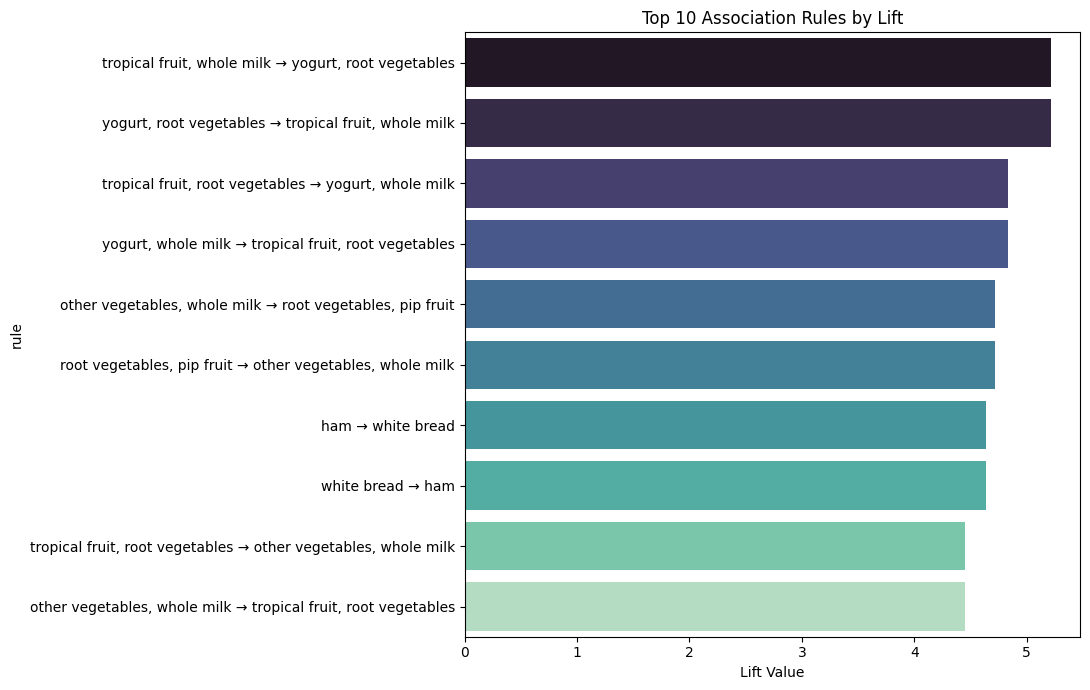

In [12]:
# Visualizations
# 2. Top Rules Bar Chart
top10 = rules_sorted.head(10).copy()
top10['antecedents_str'] = top10['antecedents'].apply(lambda x: ', '.join(list(x)))
top10['consequents_str'] = top10['consequents'].apply(lambda x: ', '.join(list(x)))
top10['rule'] = top10['antecedents_str'] + " → " + top10['consequents_str']

plt.figure(figsize=(11, 7))
sns.barplot(x='lift', y='rule', data=top10, palette='mako')
plt.title('Top 10 Association Rules by Lift')
plt.xlabel('Lift Value')
plt.tight_layout()
plt.show()

In [14]:
# Business insights
print("\n" + "="*70)
print("TOP 5 BUSINESS RECOMMENDATIONS")
print("="*70)
for i, row in rules_sorted.head(5).iterrows():
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{i+1}. If customer buys **{ante}** → Recommend **{cons}**")
    print(f"   Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}\n")


TOP 5 BUSINESS RECOMMENDATIONS
2649. If customer buys **tropical fruit, whole milk** → Recommend **yogurt, root vegetables**
   Confidence: 13.5% | Lift: 5.21

2646. If customer buys **yogurt, root vegetables** → Recommend **tropical fruit, whole milk**
   Confidence: 22.0% | Lift: 5.21

2648. If customer buys **tropical fruit, root vegetables** → Recommend **yogurt, whole milk**
   Confidence: 27.1% | Lift: 4.83

2647. If customer buys **yogurt, whole milk** → Recommend **tropical fruit, root vegetables**
   Confidence: 10.2% | Lift: 4.83

2524. If customer buys **other vegetables, whole milk** → Recommend **root vegetables, pip fruit**
   Confidence: 7.3% | Lift: 4.72

